# `EDA Notebook`
> A Machine Learning Approach for ICU Prediction in Confirmed COVID-19 Cases

## `01`  `EDA and Data Understanding` <a name="eda"></a>

**`Project`:** 
> Early ICU admission prediction for confirmed COVID-19 patients using tabular clinical data, with leakage-aware preprocessing and clinically relevant evaluation.


This notebook focuses on understanding the dataset, defining a clinically realistic prediction setup, and preparing a patient-level early-window dataset for later modelling.

**`Notebook objective:`** move from raw window-level hospital records to a clear, leakage-aware patient-level modelling design.

### `1-`  `Business / Clinical Problem` <a name="bproblem"></a>

#### `1-1`  `Problem Context` <a name="problemcontext"></a>

COVID-19 patients can deteriorate quickly, and hospitals need early signals that indicate whether a patient may require ICU care.

The clinical goal is not simply to classify records, but to support early risk identification using information available near the beginning of a patient's hospital assessment.


#### `1-2`  `Why This Problem Matters` <a name="whymatters"></a>

Early ICU prediction can support:

- patient triage
- clinical monitoring
- ICU resource planning
- earlier intervention for high-risk patients

In this project, we prioritise a clinically realistic setup over using all available data, because later observations may contain information that would not be available at early prediction time.

#### `1-3`  `Project Objective` <a name="projectobjective"></a>

The objective is to predict whether a confirmed COVID-19 patient will eventually require ICU admission using only early clinical data from the first available observation window.

### `2-`  `Technical Framing` <a name="technicalframing"></a>

#### `2-1`  `Machine Learning Problem Type` <a name="mlproblemtype"></a>

This is a **supervised binary classification** problem.

The model predicts whether a patient belongs to one of two classes:

- `0` = patient does not require ICU admission
- `1` = patient eventually requires ICU admission

#### `2-2`  `Input Features` <a name="inputfeatures"></a>

The input features include early patient information such as:

- demographic indicators
- comorbidity indicators
- blood/lab measurements
- vital signs
- derived clinical statistics

Only information available in the first observation window should be used for the final modelling dataset.

#### `2-3`  `Prediction Target` <a name="predictiontarget"></a>

The modelling target is a patient-level future ICU outcome:

`ICU_future = 1` if the patient is admitted to ICU in any window.

`ICU_future = 0` if the patient is never admitted to ICU.

This target reframes the original row-level `ICU` column into a patient-level early prediction target.

#### `2-4`  `Key Machine Learning Risk` <a name="keymlrisk"></a>

The main technical risk is **temporal leakage**.

If later windows are used as model inputs, the model may learn from information that would not be available at the intended early prediction time. This can inflate performance and make the model unrealistic.

### `3-`  `Environment Setup` <a name="environmentsetup"></a>

#### `3-1`  `Installing Analysis Packages` <a name="installpackages"></a>
Optional: run only if required in your environment

In [16]:
# Check Which Python Jupyter is Using
import sys
print(sys.executable)

C:\Users\Firaso\anaconda3\python.exe


In [17]:
# updating pip to the same Python that Jupyter is using
# !{sys.executable} -m pip install --upgrade pip

In [18]:
# install packages (missingno openpyxl) to the same Python that Jupyter is using
# !{sys.executable} -m pip install missingno openpyxl

In [19]:
# Restart kernel after installation
# import os
# os._exit(0)

#### `3-2`  `Loading Analysis Packages` <a name="loadpackages"></a>

In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Optional missing-data visualisation
try:
    import missingno as msno
    MISSINGNO_AVAILABLE = True
except ImportError:
    MISSINGNO_AVAILABLE = False

pd.set_option('display.max_columns', 250)
pd.set_option('display.max_rows', 250)

print("Packages loaded successfully.")
print("missingno available:", MISSINGNO_AVAILABLE)

Packages loaded successfully.
missingno available: True


### `4-`  `Loading Raw Data` <a name="loadrawdata"></a>

#### `4-1`  `Set Data Path` <a name="setdatapath"></a>

Update `DATA_PATH` to match where the raw dataset is stored.

Recommended project location:

`data/raw/`

In [24]:
from pathlib import Path

# The dataset is an excel file:
# Update this path to your actual dataset file
DATA_PATH = Path("../data/raw/Kaggle_Sirio_Libanes_ICU_Prediction.xlsx")


print("Expected data path:", DATA_PATH)

Expected data path: ..\data\raw\Kaggle_Sirio_Libanes_ICU_Prediction.xlsx


#### `4-2`  `Load Dataset` <a name="loaddataset"></a>

In [26]:
# The dataset is an Excel file:

import pandas as pd
df = pd.read_excel(DATA_PATH)

print("Dataset loaded.")
print("Shape:", df.shape)

Dataset loaded.
Shape: (1925, 231)


### `5-`  `Basic Data Exploration` <a name="basicexploration"></a>

#### `5-1`  `Dataset Shape` <a name="datasetshape"></a>

In [29]:
df.shape

(1925, 231)

#### `5-2`  `Column Overview` <a name="columnoverview"></a>

In [31]:
df.columns.tolist()

['PATIENT_VISIT_IDENTIFIER',
 'AGE_ABOVE65',
 'AGE_PERCENTIL',
 'GENDER',
 'DISEASE GROUPING 1',
 'DISEASE GROUPING 2',
 'DISEASE GROUPING 3',
 'DISEASE GROUPING 4',
 'DISEASE GROUPING 5',
 'DISEASE GROUPING 6',
 'HTN',
 'IMMUNOCOMPROMISED',
 'OTHER',
 'ALBUMIN_MEDIAN',
 'ALBUMIN_MEAN',
 'ALBUMIN_MIN',
 'ALBUMIN_MAX',
 'ALBUMIN_DIFF',
 'BE_ARTERIAL_MEDIAN',
 'BE_ARTERIAL_MEAN',
 'BE_ARTERIAL_MIN',
 'BE_ARTERIAL_MAX',
 'BE_ARTERIAL_DIFF',
 'BE_VENOUS_MEDIAN',
 'BE_VENOUS_MEAN',
 'BE_VENOUS_MIN',
 'BE_VENOUS_MAX',
 'BE_VENOUS_DIFF',
 'BIC_ARTERIAL_MEDIAN',
 'BIC_ARTERIAL_MEAN',
 'BIC_ARTERIAL_MIN',
 'BIC_ARTERIAL_MAX',
 'BIC_ARTERIAL_DIFF',
 'BIC_VENOUS_MEDIAN',
 'BIC_VENOUS_MEAN',
 'BIC_VENOUS_MIN',
 'BIC_VENOUS_MAX',
 'BIC_VENOUS_DIFF',
 'BILLIRUBIN_MEDIAN',
 'BILLIRUBIN_MEAN',
 'BILLIRUBIN_MIN',
 'BILLIRUBIN_MAX',
 'BILLIRUBIN_DIFF',
 'BLAST_MEDIAN',
 'BLAST_MEAN',
 'BLAST_MIN',
 'BLAST_MAX',
 'BLAST_DIFF',
 'CALCIUM_MEDIAN',
 'CALCIUM_MEAN',
 'CALCIUM_MIN',
 'CALCIUM_MAX',
 'CALCIUM_

#### `5-3`  `Preview First and Last Records` <a name="previewrecords"></a>

In [33]:
display(df.head())
display(df.tail())

,PATIENT_VISIT_IDENTIFIER,AGE_ABOVE65,AGE_PERCENTIL,GENDER,DISEASE GROUPING 1,DISEASE GROUPING 2,DISEASE GROUPING 3,DISEASE GROUPING 4,DISEASE GROUPING 5,DISEASE GROUPING 6,HTN,IMMUNOCOMPROMISED,OTHER,ALBUMIN_MEDIAN,ALBUMIN_MEAN,ALBUMIN_MIN,ALBUMIN_MAX,ALBUMIN_DIFF,BE_ARTERIAL_MEDIAN,BE_ARTERIAL_MEAN,BE_ARTERIAL_MIN,BE_ARTERIAL_MAX,BE_ARTERIAL_DIFF,BE_VENOUS_MEDIAN,BE_VENOUS_MEAN,BE_VENOUS_MIN,BE_VENOUS_MAX,BE_VENOUS_DIFF,BIC_ARTERIAL_MEDIAN,BIC_ARTERIAL_MEAN,BIC_ARTERIAL_MIN,BIC_ARTERIAL_MAX,BIC_ARTERIAL_DIFF,BIC_VENOUS_MEDIAN,BIC_VENOUS_MEAN,BIC_VENOUS_MIN,BIC_VENOUS_MAX,BIC_VENOUS_DIFF,BILLIRUBIN_MEDIAN,BILLIRUBIN_MEAN,BILLIRUBIN_MIN,BILLIRUBIN_MAX,BILLIRUBIN_DIFF,BLAST_MEDIAN,BLAST_MEAN,BLAST_MIN,BLAST_MAX,BLAST_DIFF,CALCIUM_MEDIAN,CALCIUM_MEAN,CALCIUM_MIN,CALCIUM_MAX,CALCIUM_DIFF,CREATININ_MEDIAN,CREATININ_MEAN,CREATININ_MIN,CREATININ_MAX,CREATININ_DIFF,FFA_MEDIAN,FFA_MEAN,FFA_MIN,FFA_MAX,FFA_DIFF,GGT_MEDIAN,GGT_MEAN,GGT_MIN,GGT_MAX,GGT_DIFF,GLUCOSE_MEDIAN,GLUCOSE_MEAN,GLUCOSE_MIN,GLUCOSE_MAX,GLUCOSE_DIFF,HEMATOCRITE_MEDIAN,HEMATOCRITE_MEAN,HEMATOCRITE_MIN,HEMATOCRITE_MAX,HEMATOCRITE_DIFF,HEMOGLOBIN_MEDIAN,HEMOGLOBIN_MEAN,HEMOGLOBIN_MIN,HEMOGLOBIN_MAX,HEMOGLOBIN_DIFF,INR_MEDIAN,INR_MEAN,INR_MIN,INR_MAX,INR_DIFF,LACTATE_MEDIAN,LACTATE_MEAN,LACTATE_MIN,LACTATE_MAX,LACTATE_DIFF,LEUKOCYTES_MEDIAN,LEUKOCYTES_MEAN,LEUKOCYTES_MIN,LEUKOCYTES_MAX,LEUKOCYTES_DIFF,LINFOCITOS_MEDIAN,LINFOCITOS_MEAN,LINFOCITOS_MIN,LINFOCITOS_MAX,LINFOCITOS_DIFF,NEUTROPHILES_MEDIAN,NEUTROPHILES_MEAN,NEUTROPHILES_MIN,NEUTROPHILES_MAX,NEUTROPHILES_DIFF,P02_ARTERIAL_MEDIAN,P02_ARTERIAL_MEAN,P02_ARTERIAL_MIN,P02_ARTERIAL_MAX,P02_ARTERIAL_DIFF,P02_VENOUS_MEDIAN,P02_VENOUS_MEAN,P02_VENOUS_MIN,P02_VENOUS_MAX,P02_VENOUS_DIFF,PC02_ARTERIAL_MEDIAN,PC02_ARTERIAL_MEAN,PC02_ARTERIAL_MIN,PC02_ARTERIAL_MAX,PC02_ARTERIAL_DIFF,PC02_VENOUS_MEDIAN,PC02_VENOUS_MEAN,PC02_VENOUS_MIN,PC02_VENOUS_MAX,PC02_VENOUS_DIFF,PCR_MEDIAN,PCR_MEAN,PCR_MIN,PCR_MAX,PCR_DIFF,PH_ARTERIAL_MEDIAN,PH_ARTERIAL_MEAN,PH_ARTERIAL_MIN,PH_ARTERIAL_MAX,PH_ARTERIAL_DIFF,PH_VENOUS_MEDIAN,PH_VENOUS_MEAN,PH_VENOUS_MIN,PH_VENOUS_MAX,PH_VENOUS_DIFF,PLATELETS_MEDIAN,PLATELETS_MEAN,PLATELETS_MIN,PLATELETS_MAX,PLATELETS_DIFF,POTASSIUM_MEDIAN,POTASSIUM_MEAN,POTASSIUM_MIN,POTASSIUM_MAX,POTASSIUM_DIFF,SAT02_ARTERIAL_MEDIAN,SAT02_ARTERIAL_MEAN,SAT02_ARTERIAL_MIN,SAT02_ARTERIAL_MAX,SAT02_ARTERIAL_DIFF,SAT02_VENOUS_MEDIAN,SAT02_VENOUS_MEAN,SAT02_VENOUS_MIN,SAT02_VENOUS_MAX,SAT02_VENOUS_DIFF,SODIUM_MEDIAN,SODIUM_MEAN,SODIUM_MIN,SODIUM_MAX,SODIUM_DIFF,TGO_MEDIAN,TGO_MEAN,TGO_MIN,TGO_MAX,TGO_DIFF,TGP_MEDIAN,TGP_MEAN,TGP_MIN,TGP_MAX,TGP_DIFF,TTPA_MEDIAN,TTPA_MEAN,TTPA_MIN,TTPA_MAX,TTPA_DIFF,UREA_MEDIAN,UREA_MEAN,UREA_MIN,UREA_MAX,UREA_DIFF,DIMER_MEDIAN,DIMER_MEAN,DIMER_MIN,DIMER_MAX,DIMER_DIFF,BLOODPRESSURE_DIASTOLIC_MEAN,BLOODPRESSURE_SISTOLIC_MEAN,HEART_RATE_MEAN,RESPIRATORY_RATE_MEAN,TEMPERATURE_MEAN,OXYGEN_SATURATION_MEAN,BLOODPRESSURE_DIASTOLIC_MEDIAN,BLOODPRESSURE_SISTOLIC_MEDIAN,HEART_RATE_MEDIAN,RESPIRATORY_RATE_MEDIAN,TEMPERATURE_MEDIAN,OXYGEN_SATURATION_MEDIAN,BLOODPRESSURE_DIASTOLIC_MIN,BLOODPRESSURE_SISTOLIC_MIN,HEART_RATE_MIN,RESPIRATORY_RATE_MIN,TEMPERATURE_MIN,OXYGEN_SATURATION_MIN,BLOODPRESSURE_DIASTOLIC_MAX,BLOODPRESSURE_SISTOLIC_MAX,HEART_RATE_MAX,RESPIRATORY_RATE_MAX,TEMPERATURE_MAX,OXYGEN_SATURATION_MAX,BLOODPRESSURE_DIASTOLIC_DIFF,BLOODPRESSURE_SISTOLIC_DIFF,HEART_RATE_DIFF,RESPIRATORY_RATE_DIFF,TEMPERATURE_DIFF,OXYGEN_SATURATION_DIFF,BLOODPRESSURE_DIASTOLIC_DIFF_REL,BLOODPRESSURE_SISTOLIC_DIFF_REL,HEART_RATE_DIFF_REL,RESPIRATORY_RATE_DIFF_REL,TEMPERATURE_DIFF_REL,OXYGEN_SATURATION_DIFF_REL,WINDOW,ICU
0,0,1,60th,0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

,PATIENT_VISIT_IDENTIFIER,AGE_ABOVE65,AGE_PERCENTIL,GENDER,DISEASE GROUPING 1,DISEASE GROUPING 2,DISEASE GROUPING 3,DISEASE GROUPING 4,DISEASE GROUPING 5,DISEASE GROUPING 6,HTN,IMMUNOCOMPROMISED,OTHER,ALBUMIN_MEDIAN,ALBUMIN_MEAN,ALBUMIN_MIN,ALBUMIN_MAX,ALBUMIN_DIFF,BE_ARTERIAL_MEDIAN,BE_ARTERIAL_MEAN,BE_ARTERIAL_MIN,BE_ARTERIAL_MAX,BE_ARTERIAL_DIFF,BE_VENOUS_MEDIAN,BE_VENOUS_MEAN,BE_VENOUS_MIN,BE_VENOUS_MAX,BE_VENOUS_DIFF,BIC_ARTERIAL_MEDIAN,BIC_ARTERIAL_MEAN,BIC_ARTERIAL_MIN,BIC_ARTERIAL_MAX,BIC_ARTERIAL_DIFF,BIC_VENOUS_MEDIAN,BIC_VENOUS_MEAN,BIC_VENOUS_MIN,BIC_VENOUS_MAX,BIC_VENOUS_DIFF,BILLIRUBIN_MEDIAN,BILLIRUBIN_MEAN,BILLIRUBIN_MIN,BILLIRUBIN_MAX,BILLIRUBIN_DIFF,BLAST_MEDIAN,BLAST_MEAN,BLAST_MIN,BLAST_MAX,BLAST_DIFF,CALCIUM_MEDIAN,CALCIUM_MEAN,CALCIUM_MIN,CALCIUM_MAX,CALCIUM_DIFF,CREATININ_MEDIAN,CREATININ_MEAN,CREATININ_MIN,CREATININ_MAX,CREATININ_DIFF,FFA_MEDIAN,FFA_MEAN,FFA_MIN,FFA_MAX,FFA_DIFF,GGT_MEDIAN,GGT_MEAN,GGT_MIN,GGT_MAX,GGT_DIFF,GLUCOSE_MEDIAN,GLUCOSE_MEAN,GLUCOSE_MIN,GLUCOSE_MAX,GLUCOSE_DIFF,HEMATOCRITE_MEDIAN,HEMATOCRITE_MEAN,HEMATOCRITE_MIN,HEMATOCRITE_MAX,HEMATOCRITE_DIFF,HEMOGLOBIN_MEDIAN,HEMOGLOBIN_MEAN,HEMOGLOBIN_MIN,HEMOGLOBIN_MAX,HEMOGLOBIN_DIFF,INR_MEDIAN,INR_MEAN,INR_MIN,INR_MAX,INR_DIFF,LACTATE_MEDIAN,LACTATE_MEAN,LACTATE_MIN,LACTATE_MAX,LACTATE_DIFF,LEUKOCYTES_MEDIAN,LEUKOCYTES_MEAN,LEUKOCYTES_MIN,LEUKOCYTES_MAX,LEUKOCYTES_DIFF,LINFOCITOS_MEDIAN,LINFOCITOS_MEAN,LINFOCITOS_MIN,LINFOCITOS_MAX,LINFOCITOS_DIFF,NEUTROPHILES_MEDIAN,NEUTROPHILES_MEAN,NEUTROPHILES_MIN,NEUTROPHILES_MAX,NEUTROPHILES_DIFF,P02_ARTERIAL_MEDIAN,P02_ARTERIAL_MEAN,P02_ARTERIAL_MIN,P02_ARTERIAL_MAX,P02_ARTERIAL_DIFF,P02_VENOUS_MEDIAN,P02_VENOUS_MEAN,P02_VENOUS_MIN,P02_VENOUS_MAX,P02_VENOUS_DIFF,PC02_ARTERIAL_MEDIAN,PC02_ARTERIAL_MEAN,PC02_ARTERIAL_MIN,PC02_ARTERIAL_MAX,PC02_ARTERIAL_DIFF,PC02_VENOUS_MEDIAN,PC02_VENOUS_MEAN,PC02_VENOUS_MIN,PC02_VENOUS_MAX,PC02_VENOUS_DIFF,PCR_MEDIAN,PCR_MEAN,PCR_MIN,PCR_MAX,PCR_DIFF,PH_ARTERIAL_MEDIAN,PH_ARTERIAL_MEAN,PH_ARTERIAL_MIN,PH_ARTERIAL_MAX,PH_ARTERIAL_DIFF,PH_VENOUS_MEDIAN,PH_VENOUS_MEAN,PH_VENOUS_MIN,PH_VENOUS_MAX,PH_VENOUS_DIFF,PLATELETS_MEDIAN,PLATELETS_MEAN,PLATELETS_MIN,PLATELETS_MAX,PLATELETS_DIFF,POTASSIUM_MEDIAN,POTASSIUM_MEAN,POTASSIUM_MIN,POTASSIUM_MAX,POTASSIUM_DIFF,SAT02_ARTERIAL_MEDIAN,SAT02_ARTERIAL_MEAN,SAT02_ARTERIAL_MIN,SAT02_ARTERIAL_MAX,SAT02_ARTERIAL_DIFF,SAT02_VENOUS_MEDIAN,SAT02_VENOUS_MEAN,SAT02_VENOUS_MIN,SAT02_VENOUS_MAX,SAT02_VENOUS_DIFF,SODIUM_MEDIAN,SODIUM_MEAN,SODIUM_MIN,SODIUM_MAX,SODIUM_DIFF,TGO_MEDIAN,TGO_MEAN,TGO_MIN,TGO_MAX,TGO_DIFF,TGP_MEDIAN,TGP_MEAN,TGP_MIN,TGP_MAX,TGP_DIFF,TTPA_MEDIAN,TTPA_MEAN,TTPA_MIN,TTPA_MAX,TTPA_DIFF,UREA_MEDIAN,UREA_MEAN,UREA_MIN,UREA_MAX,UREA_DIFF,DIMER_MEDIAN,DIMER_MEAN,DIMER_MIN,DIMER_MAX,DIMER_DIFF,BLOODPRESSURE_DIASTOLIC_MEAN,BLOODPRESSURE_SISTOLIC_MEAN,HEART_RATE_MEAN,RESPIRATORY_RATE_MEAN,TEMPERATURE_MEAN,OXYGEN_SATURATION_MEAN,BLOODPRESSURE_DIASTOLIC_MEDIAN,BLOODPRESSURE_SISTOLIC_MEDIAN,HEART_RATE_MEDIAN,RESPIRATORY_RATE_MEDIAN,TEMPERATURE_MEDIAN,OXYGEN_SATURATION_MEDIAN,BLOODPRESSURE_DIASTOLIC_MIN,BLOODPRESSURE_SISTOLIC_MIN,HEART_RATE_MIN,RESPIRATORY_RATE_MIN,TEMPERATURE_MIN,OXYGEN_SATURATION_MIN,BLOODPRESSURE_DIASTOLIC_MAX,BLOODPRESSURE_SISTOLIC_MAX,HEART_RATE_MAX,RESPIRATORY_RATE_MAX,TEMPERATURE_MAX,OXYGEN_SATURATION_MAX,BLOODPRESSURE_DIASTOLIC_DIFF,BLOODPRESSURE_SISTOLIC_DIFF,HEART_RATE_DIFF,RESPIRATORY_RATE_DIFF,TEMPERATURE_DIFF,OXYGEN_SATURATION_DIFF,BLOODPRESSURE_DIASTOLIC_DIFF_REL,BLOODPRESSURE_SISTOLIC_DIFF_REL,HEART_RATE_DIFF_REL,RESPIRATORY_RATE_DIFF_REL,TEMPERATURE_DIFF_REL,OXYGEN_SATURATION_DIFF_REL,WINDOW,ICU
1920,384,0,50th,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

#### `5-4`  `Dataset Information` <a name="datasetinfo"></a>

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1925 entries, 0 to 1924
Columns: 231 entries, PATIENT_VISIT_IDENTIFIER to ICU
dtypes: float64(225), int64(4), object(2)
memory usage: 3.4+ MB


The high-level structure:

- 1925 rows
- 231 columns
- 225 float columns
- 4 integer columns
- 2 object columns
- object columns: `AGE_PERCENTIL`, `WINDOW`

#### `5-5`  `Statistical Summary` <a name="statisticalsummary"></a>

In [38]:
# The .T at the end of df.describe().T transposes the result of df.describe().
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PATIENT_VISIT_IDENTIFIER,1925.0,192.000000,111.168431,0.0,96.000000,192.000000,288.000000,384.0
AGE_ABOVE65,1925.0,0.467532,0.499074,0.0,0.000000,0.000000,1.000000,1.0
GENDER,1925.0,0.368831,0.482613,0.0,0.000000,0.000000,1.000000,1.0
DISEASE GROUPING 1,1920.0,0.108333,0.310882,0.0,0.000000,0.000000,0.000000,1.0
DISEASE GROUPING 2,1920.0,0.028125,0.165373,0.0,0.000000,0.000000,0.000000,1.0
DISEASE GROUPING 3,1920.0,0.097917,0.297279,0.0,0.000000,0.000000,0.000000,1.0
DISEASE GROUPING 4,1920.0,0.019792,0.139320,0.0,0.000000,0.000000,0.000000,1.0
DISEASE GROUPING 5,1920.0,0.128125,0.334316,0.0,0.000000,0.000000,0.000000,1.0
DISEASE GROUPING 6,1920.0,0.046875,0.211426,0.0,0.000000,0.000000,0.000000,1.0
HTN,1920.0,0.213021,0.409549,0.0,0.000000,0.000000,0.000000,1.0


Important observations:

- `ICU` is binary.
- Many numerical features are already scaled around `-1` to `+1`.
- Several variables contain missing values.
- Some variables may have zero standard deviation and will need attention later.

#### `5-6`  `Data Type Summary` <a name="datatypesummary"></a>

In [41]:
df.dtypes.value_counts()

float64    225
int64        4
object       2
Name: count, dtype: int64

#### `5-7`  `Patient Identifier Exploration` <a name="patientidentifier"></a>

In [43]:
num_patients = df['PATIENT_VISIT_IDENTIFIER'].nunique()
print("Number of unique patients:", num_patients)

Number of unique patients: 385


Patient Identifier (Key Concept)

- `PATIENT_VISIT_IDENTIFIER` is a **unique identifier for each patient**
- Each patient has **exactly one identifier**
- The same patient appears in **multiple rows**, corresponding to different time windows

**Example:**

Patient with `PATIENT_VISIT_IDENTIFIER = 339`

| WINDOW   | ICU |
|----------|-----|
| 0–2      | 0   |
| 2–4      | 0   |
| 4–6      | 1   |
| 6–12     | 1   |
| ABOVE_12 | 1   |

- These 5 rows represent **the same patient over time**
- As shown above, this patient was not in ICU at 0–2 but was admitted later.

Observasion:
> In this dataset, the unit of observation is initially a patient-time window, but the unit of prediction is the patient.

#### `5-8`  `Window Exploration` <a name="windowexploration"></a>

In [47]:
df['WINDOW'].unique()

array(['0-2', '2-4', '4-6', '6-12', 'ABOVE_12'], dtype=object)

In [48]:
df['WINDOW'].value_counts().sort_index()

WINDOW
0-2         385
2-4         385
4-6         385
6-12        385
ABOVE_12    385
Name: count, dtype: int64

The dataset contains multiple observation windows per patient, which is central to the leakage-risk and will need attention later

#### `5-9`  `Age Category Exploration` <a name="agecategory"></a>

In [51]:
df['AGE_PERCENTIL'].unique()

array(['60th', '90th', '10th', '40th', '70th', '20th', '50th', '80th',
       '30th', 'Above 90th'], dtype=object)

In [52]:
df['AGE_PERCENTIL'].value_counts().sort_index()

AGE_PERCENTIL
10th          205
20th          215
30th          205
40th          200
50th          190
60th          185
70th          195
80th          190
90th          155
Above 90th    185
Name: count, dtype: int64

#### `5-10`  `Gender Distribution` <a name="genderdistribution"></a>

In [54]:
df['GENDER'].value_counts()

GENDER
0    1215
1     710
Name: count, dtype: int64

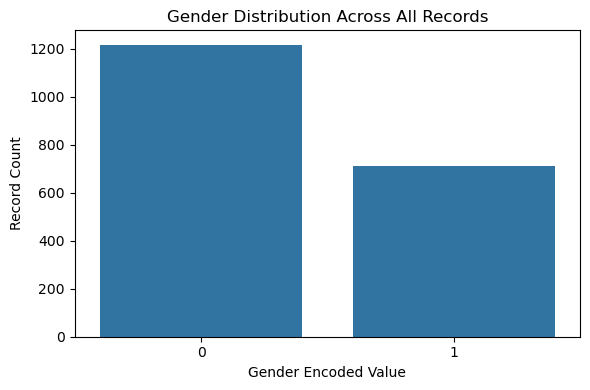

In [55]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='GENDER')
plt.title('Gender Distribution Across All Records')
plt.xlabel('Gender Encoded Value')
plt.ylabel('Record Count')
plt.tight_layout()
plt.show()

#### `5-11`  `Row-Level ICU Distribution` <a name="rowlevelicu"></a>

In [57]:
print("Row-level ICU counts:")
print(df['ICU'].value_counts().sort_index())

print("------------------- \n")
print("Row-level ICU proportions:")
print(df['ICU'].value_counts(normalize=True).sort_index())

print("------------------- \n")
print("ICU statistical summary:")
print(df['ICU'].describe())

Row-level ICU counts:
ICU
0    1410
1     515
Name: count, dtype: int64
------------------- 

Row-level ICU proportions:
ICU
0    0.732468
1    0.267532
Name: proportion, dtype: float64
------------------- 

ICU statistical summary:
count    1925.000000
mean        0.267532
std         0.442787
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: ICU, dtype: float64


Important:

The raw row-level ICU distribution is not the final modelling target distribution, because each patient appears across multiple time windows.

---

#### `5-12`  `Patient-Level ICU Distribution` <a name="patientlevelicu"></a>

In [60]:
patient_icu = df.groupby('PATIENT_VISIT_IDENTIFIER')['ICU'].max()

print("Patient-level ICU counts:")
print(patient_icu.value_counts().sort_index())

print("------------------- \n")
print("Patient-level ICU proportions:")
print(patient_icu.value_counts(normalize=True).sort_index())

print("------------------- \n")

Patient-level ICU counts:
ICU
0    190
1    195
Name: count, dtype: int64
------------------- 

Patient-level ICU proportions:
ICU
0    0.493506
1    0.506494
Name: proportion, dtype: float64
------------------- 



The patient-level distribution:

- `0` = 190 patients not admitted to ICU
- `1` = 195 patients admitted to ICU

This is the relevant target distribution for the final patient-level modelling setup.

---

#### `5-13`  `Admission Cases by Window` <a name="admissionbywindow"></a>

In [63]:
admission_cases_by_window = (
    df[df['ICU'] == 1]
    .groupby('WINDOW')['PATIENT_VISIT_IDENTIFIER']
    .nunique()
    .reindex(['0-2', '2-4', '4-6', '6-12', 'ABOVE_12'])
)

print("Admission cases by window:")
print(admission_cases_by_window)

Admission cases by window:
WINDOW
0-2          32
2-4          59
4-6          99
6-12        130
ABOVE_12    195
Name: PATIENT_VISIT_IDENTIFIER, dtype: int64


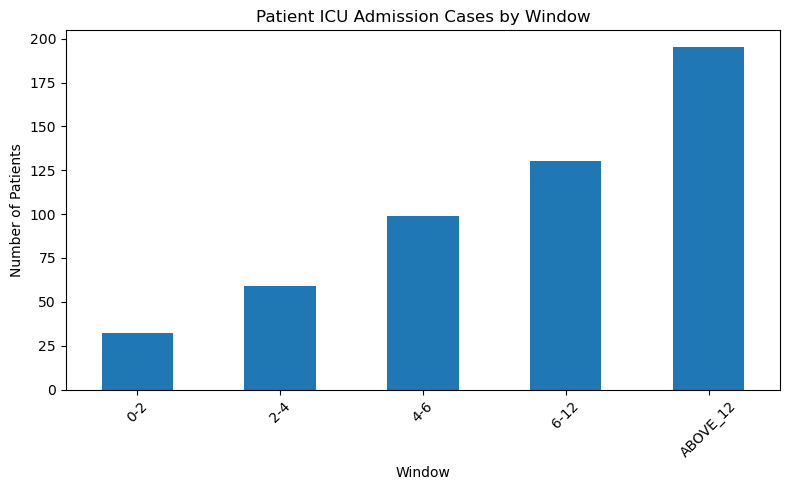

In [64]:
plt.figure(figsize=(8, 5))
admission_cases_by_window.plot(kind='bar')
plt.title('Patient ICU Admission Cases by Window')
plt.xlabel('Window')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### `5-14`  `Patient-Level Admission vs Non-Admission Plot` <a name="patientadmissionplot"></a>

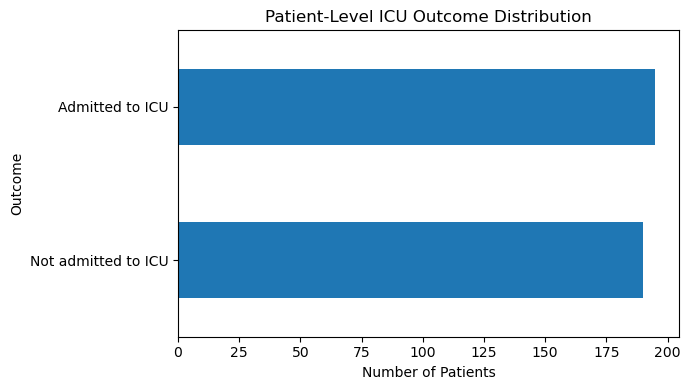

In [66]:
patient_icu_counts = patient_icu.value_counts().sort_index()
patient_icu_counts.index = ['Not admitted to ICU', 'Admitted to ICU']

plt.figure(figsize=(7, 4))
patient_icu_counts.plot(kind='barh')
plt.title('Patient-Level ICU Outcome Distribution')
plt.xlabel('Number of Patients')
plt.ylabel('Outcome')
plt.tight_layout()
plt.show()

### `6-`  `Define Data Strategy and Prediction Setup` <a name="datastrategy"></a>

#### `6-1`  `What Is One Training Sample?` <a name="trainingsample"></a>

**One training sample = one patient.**

This avoids treating repeated windows from the same patient as independent examples.

#### `6-2`  `Prediction Time Window` <a name="predictionwindow"></a>

We will use only:

`WINDOW == "0-2"`

This simulates an early prediction setting and avoids using later clinical information.

#### `6-3`  `Target Definition` <a name="targetdefinition"></a>

`ICU_future = 1` if the patient has `ICU = 1` in any window.

`ICU_future = 0` otherwise.

This means the model uses early information to predict whether the patient will ever require ICU care.

#### `6-4`  `Why Later Windows Are Excluded` <a name="excludelaterwindows"></a>

Later windows may contain signs of clinical deterioration that are too close to ICU admission or occur after ICU admission.

Using them as input would create temporal leakage and could lead to over-optimistic and artificially inflated performance.

#### `6-5`  `What If ICU Happens in the 0-2 Window?` <a name="icuinitialwindow"></a>

Patients admitted to ICU in the first window are kept as positive cases.

They represent severe cases already identifiable at the earliest observation point.

#### `6-6`  `Trade-Off` <a name="tradeoff"></a>

By using only the 0-2 window, we lose later information but gain:

- clinical realism
- leakage prevention
- one row per patient
- cleaner evaluation

**`Data Strategy Summary`**

To avoid temporal leakage and ensure clinically realistic prediction, the dataset is restricted to the first observation window (0-2 hours), ensuring each patient is represented once using only early clinical information.

The target variable is defined at the patient level, indicating whether the patient was ever admitted to the ICU during their hospital stay.

### `7-`  `Build Patient-Level Early Dataset` <a name="earlydataset"></a>

#### `7-1`  `Create Patient-Level ICU Target` <a name="createpatienttarget"></a>

In [77]:
# Identify patients who were (ever) admitted to ICU in any window
icu_patients = set(
    df.loc[df['ICU'] == 1, 'PATIENT_VISIT_IDENTIFIER'].unique()
)

print("Number of patients who ever had ICU:", len(icu_patients))

Number of patients who ever had ICU: 195


#### `7-2`  `Filter to the First Observation Window` <a name="filterfirstwindow"></a>

In [79]:
df_early = df[df['WINDOW'] == '0-2'].copy()

print("Shape after keeping only WINDOW == '0-2':", df_early.shape)

Shape after keeping only WINDOW == '0-2': (385, 231)


In [80]:
df_early.head()

,PATIENT_VISIT_IDENTIFIER,AGE_ABOVE65,AGE_PERCENTIL,GENDER,DISEASE GROUPING 1,DISEASE GROUPING 2,DISEASE GROUPING 3,DISEASE GROUPING 4,DISEASE GROUPING 5,DISEASE GROUPING 6,HTN,IMMUNOCOMPROMISED,OTHER,ALBUMIN_MEDIAN,ALBUMIN_MEAN,ALBUMIN_MIN,ALBUMIN_MAX,ALBUMIN_DIFF,BE_ARTERIAL_MEDIAN,BE_ARTERIAL_MEAN,BE_ARTERIAL_MIN,BE_ARTERIAL_MAX,BE_ARTERIAL_DIFF,BE_VENOUS_MEDIAN,BE_VENOUS_MEAN,BE_VENOUS_MIN,BE_VENOUS_MAX,BE_VENOUS_DIFF,BIC_ARTERIAL_MEDIAN,BIC_ARTERIAL_MEAN,BIC_ARTERIAL_MIN,BIC_ARTERIAL_MAX,BIC_ARTERIAL_DIFF,BIC_VENOUS_MEDIAN,BIC_VENOUS_MEAN,BIC_VENOUS_MIN,BIC_VENOUS_MAX,BIC_VENOUS_DIFF,BILLIRUBIN_MEDIAN,BILLIRUBIN_MEAN,BILLIRUBIN_MIN,BILLIRUBIN_MAX,BILLIRUBIN_DIFF,BLAST_MEDIAN,BLAST_MEAN,BLAST_MIN,BLAST_MAX,BLAST_DIFF,CALCIUM_MEDIAN,CALCIUM_MEAN,CALCIUM_MIN,CALCIUM_MAX,CALCIUM_DIFF,CREATININ_MEDIAN,CREATININ_MEAN,CREATININ_MIN,CREATININ_MAX,CREATININ_DIFF,FFA_MEDIAN,FFA_MEAN,FFA_MIN,FFA_MAX,FFA_DIFF,GGT_MEDIAN,GGT_MEAN,GGT_MIN,GGT_MAX,GGT_DIFF,GLUCOSE_MEDIAN,GLUCOSE_MEAN,GLUCOSE_MIN,GLUCOSE_MAX,GLUCOSE_DIFF,HEMATOCRITE_MEDIAN,HEMATOCRITE_MEAN,HEMATOCRITE_MIN,HEMATOCRITE_MAX,HEMATOCRITE_DIFF,HEMOGLOBIN_MEDIAN,HEMOGLOBIN_MEAN,HEMOGLOBIN_MIN,HEMOGLOBIN_MAX,HEMOGLOBIN_DIFF,INR_MEDIAN,INR_MEAN,INR_MIN,INR_MAX,INR_DIFF,LACTATE_MEDIAN,LACTATE_MEAN,LACTATE_MIN,LACTATE_MAX,LACTATE_DIFF,LEUKOCYTES_MEDIAN,LEUKOCYTES_MEAN,LEUKOCYTES_MIN,LEUKOCYTES_MAX,LEUKOCYTES_DIFF,LINFOCITOS_MEDIAN,LINFOCITOS_MEAN,LINFOCITOS_MIN,LINFOCITOS_MAX,LINFOCITOS_DIFF,NEUTROPHILES_MEDIAN,NEUTROPHILES_MEAN,NEUTROPHILES_MIN,NEUTROPHILES_MAX,NEUTROPHILES_DIFF,P02_ARTERIAL_MEDIAN,P02_ARTERIAL_MEAN,P02_ARTERIAL_MIN,P02_ARTERIAL_MAX,P02_ARTERIAL_DIFF,P02_VENOUS_MEDIAN,P02_VENOUS_MEAN,P02_VENOUS_MIN,P02_VENOUS_MAX,P02_VENOUS_DIFF,PC02_ARTERIAL_MEDIAN,PC02_ARTERIAL_MEAN,PC02_ARTERIAL_MIN,PC02_ARTERIAL_MAX,PC02_ARTERIAL_DIFF,PC02_VENOUS_MEDIAN,PC02_VENOUS_MEAN,PC02_VENOUS_MIN,PC02_VENOUS_MAX,PC02_VENOUS_DIFF,PCR_MEDIAN,PCR_MEAN,PCR_MIN,PCR_MAX,PCR_DIFF,PH_ARTERIAL_MEDIAN,PH_ARTERIAL_MEAN,PH_ARTERIAL_MIN,PH_ARTERIAL_MAX,PH_ARTERIAL_DIFF,PH_VENOUS_MEDIAN,PH_VENOUS_MEAN,PH_VENOUS_MIN,PH_VENOUS_MAX,PH_VENOUS_DIFF,PLATELETS_MEDIAN,PLATELETS_MEAN,PLATELETS_MIN,PLATELETS_MAX,PLATELETS_DIFF,POTASSIUM_MEDIAN,POTASSIUM_MEAN,POTASSIUM_MIN,POTASSIUM_MAX,POTASSIUM_DIFF,SAT02_ARTERIAL_MEDIAN,SAT02_ARTERIAL_MEAN,SAT02_ARTERIAL_MIN,SAT02_ARTERIAL_MAX,SAT02_ARTERIAL_DIFF,SAT02_VENOUS_MEDIAN,SAT02_VENOUS_MEAN,SAT02_VENOUS_MIN,SAT02_VENOUS_MAX,SAT02_VENOUS_DIFF,SODIUM_MEDIAN,SODIUM_MEAN,SODIUM_MIN,SODIUM_MAX,SODIUM_DIFF,TGO_MEDIAN,TGO_MEAN,TGO_MIN,TGO_MAX,TGO_DIFF,TGP_MEDIAN,TGP_MEAN,TGP_MIN,TGP_MAX,TGP_DIFF,TTPA_MEDIAN,TTPA_MEAN,TTPA_MIN,TTPA_MAX,TTPA_DIFF,UREA_MEDIAN,UREA_MEAN,UREA_MIN,UREA_MAX,UREA_DIFF,DIMER_MEDIAN,DIMER_MEAN,DIMER_MIN,DIMER_MAX,DIMER_DIFF,BLOODPRESSURE_DIASTOLIC_MEAN,BLOODPRESSURE_SISTOLIC_MEAN,HEART_RATE_MEAN,RESPIRATORY_RATE_MEAN,TEMPERATURE_MEAN,OXYGEN_SATURATION_MEAN,BLOODPRESSURE_DIASTOLIC_MEDIAN,BLOODPRESSURE_SISTOLIC_MEDIAN,HEART_RATE_MEDIAN,RESPIRATORY_RATE_MEDIAN,TEMPERATURE_MEDIAN,OXYGEN_SATURATION_MEDIAN,BLOODPRESSURE_DIASTOLIC_MIN,BLOODPRESSURE_SISTOLIC_MIN,HEART_RATE_MIN,RESPIRATORY_RATE_MIN,TEMPERATURE_MIN,OXYGEN_SATURATION_MIN,BLOODPRESSURE_DIASTOLIC_MAX,BLOODPRESSURE_SISTOLIC_MAX,HEART_RATE_MAX,RESPIRATORY_RATE_MAX,TEMPERATURE_MAX,OXYGEN_SATURATION_MAX,BLOODPRESSURE_DIASTOLIC_DIFF,BLOODPRESSURE_SISTOLIC_DIFF,HEART_RATE_DIFF,RESPIRATORY_RATE_DIFF,TEMPERATURE_DIFF,OXYGEN_SATURATION_DIFF,BLOODPRESSURE_DIASTOLIC_DIFF_REL,BLOODPRESSURE_SISTOLIC_DIFF_REL,HEART_RATE_DIFF_REL,RESPIRATORY_RATE_DIFF_REL,TEMPERATURE_DIFF_REL,OXYGEN_SATURATION_DIFF_REL,WINDOW,ICU
0,0,1,60th,0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

#### `7-3`  `Assign Future ICU Target` <a name="assignfuturetarget"></a>

> To align the model with the clinical objective of early prediction, the target variable was redefined as whether the patient was ever admitted to the ICU, rather than ICU status at a specific time window.

In [83]:
# icu_patients: Identify patients who were (ever) admitted to ICU in any window

df_early['ICU'] = df_early['PATIENT_VISIT_IDENTIFIER'].isin(icu_patients).astype(int)

print("Patient-level target assigned.")

Patient-level target assigned.


In [84]:
# Updated ICU target (ICU_future)
# Now reflects whether the patient was EVER admitted to ICU across any time window
# This is the final prediction target used for modeling

df_early['ICU']

0       1
5       1
10      1
15      0
20      0
       ..
1900    1
1905    0
1910    1
1915    0
1920    0
Name: ICU, Length: 385, dtype: int32

Before vs After ICU Definition

To clarify how the target variable is constructed, consider the following example:

**Example: Patient with `PATIENT_VISIT_IDENTIFIER =2`**

- **Before (Step 7.2)**  
  ICU =-0  
  → Indicates the patient was **not in ICU during the first 0–2 hour window**  
  → This is an **early-time snapshot only**

- **After (Step 7.3)**  
  -CU = 1  
  → Indicates the patient was **eventually admitted to ICU at a later time -window (ABOVE_12)**  
  → This becomes the **final prediction target (ICU_future)**

This transformation ensures that the model predicts **future ICU admission using only early clinical data**, avoiding `temporal leakage`.

In [86]:
# Example: Patient with `PATIENT_VISIT_IDENTIFIER =2
patient_id = 2
df[df['PATIENT_VISIT_IDENTIFIER'] == patient_id][['WINDOW', 'ICU']]

,WINDOW,ICU
10,0-2,0
11,2-4,0
12,4-6,0
13,6-12,0
14,ABOVE_12,1


`Observation`
- As shown above, this patient was not in ICU at 0–2 but was admitted later  time -window (ABOVE_12).

---

#### `7-4`  `Verify One Row Per Patient` <a name="verifyonerow"></a>

In [89]:
print("Number of rows:", len(df_early))
print("Number of unique patients:", df_early['PATIENT_VISIT_IDENTIFIER'].nunique())

patient_counts = df_early['PATIENT_VISIT_IDENTIFIER'].value_counts()
duplicated_patients = patient_counts[patient_counts > 1]

print("Number of patients appearing more than once:", len(duplicated_patients))

if len(duplicated_patients) > 0:
    display(duplicated_patients)
else:
    print("No duplicated patients. Good: one row per patient.")

Number of rows: 385
Number of unique patients: 385
Number of patients appearing more than once: 0
No duplicated patients. Good: one row per patient.


`Validation`:

- 385 rows
- 385 unique patients
- 0 duplicated patients

#### `7-5`  `Verify Final Target Distribution` <a name="verifytargetdist"></a>

In [92]:
print("Final patient-level ICU target distribution:")
print(df_early['ICU'].value_counts().sort_index())

print("------------------- \n")
print("Final patient-level ICU target proportions:")
print(df_early['ICU'].value_counts(normalize=True).sort_index())

print("------------------- \n")


Final patient-level ICU target distribution:
ICU
0    190
1    195
Name: count, dtype: int64
------------------- 

Final patient-level ICU target proportions:
ICU
0    0.493506
1    0.506494
Name: proportion, dtype: float64
------------------- 



`Validation`:

- `0` = 190
- `1` = 195

The final target is nearly balanced at patient level.

---

### `8-`  `Missing Data Analysis` <a name="missinganalysis"></a>

#### `8-1`  `Missing Percentage Per Feature` <a name="missingpercentage"></a>

In [96]:
missing_ratio = df_early.isnull().mean().sort_values(ascending=False)
missing_ratio.head(20)

RESPIRATORY_RATE_DIFF_REL     0.696104
RESPIRATORY_RATE_DIFF         0.696104
RESPIRATORY_RATE_MEDIAN       0.696104
RESPIRATORY_RATE_MAX          0.696104
RESPIRATORY_RATE_MEAN         0.696104
RESPIRATORY_RATE_MIN          0.696104
TEMPERATURE_DIFF              0.683117
TEMPERATURE_MEAN              0.683117
TEMPERATURE_MAX               0.683117
TEMPERATURE_DIFF_REL          0.683117
TEMPERATURE_MEDIAN            0.683117
TEMPERATURE_MIN               0.683117
OXYGEN_SATURATION_DIFF        0.664935
OXYGEN_SATURATION_MEDIAN      0.664935
OXYGEN_SATURATION_MAX         0.664935
OXYGEN_SATURATION_DIFF_REL    0.664935
OXYGEN_SATURATION_MIN         0.664935
OXYGEN_SATURATION_MEAN        0.664935
HEART_RATE_MEAN               0.654545
HEART_RATE_MEDIAN             0.654545
dtype: float64

#### `8-2`  `Top 20 Features by Missing Percentage` <a name="topmissingpercentage"></a>

In [98]:
top_20_missing = missing_ratio.head(20)

display(top_20_missing.to_frame(name='missing_ratio'))

,missing_ratio
RESPIRATORY_RATE_DIFF_REL,0.696104
RESPIRATORY_RATE_DIFF,0.696104
RESPIRATORY_RATE_MEDIAN,0.696104
RESPIRATORY_RATE_MAX,0.696104
RESPIRATORY_RATE_MEAN,0.696104
RESPIRATORY_RATE_MIN,0.696104
TEMPERATURE_DIFF,0.683117
TEMPERATURE_MEAN,0.683117
TEMPERATURE_MAX,0.683117
TEMPERATURE_DIFF_REL,0.683117


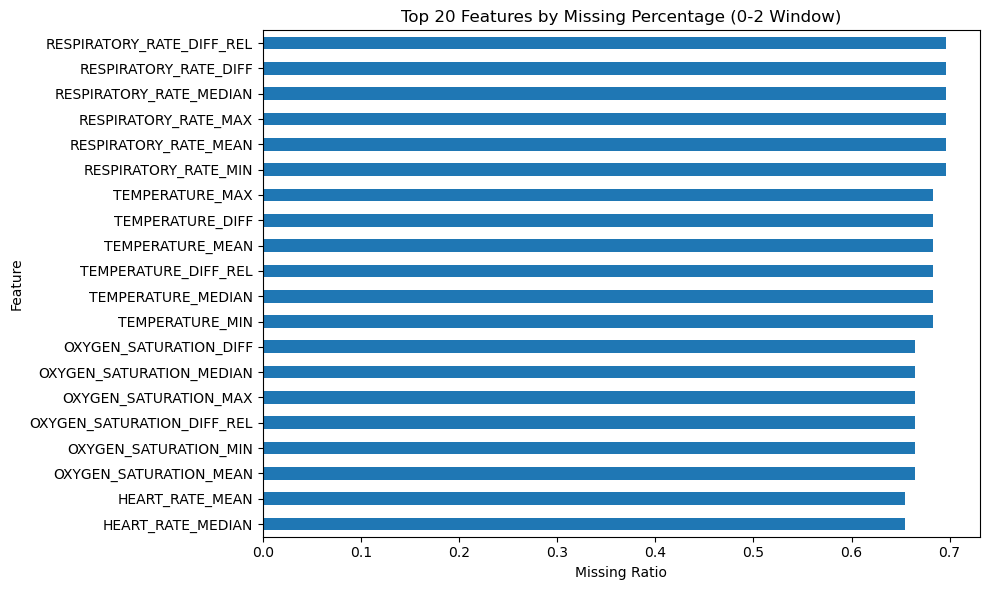

In [99]:
plt.figure(figsize=(10, 6))
top_20_missing.sort_values().plot(kind='barh')
plt.title('Top 20 Features by Missing Percentage (0-2 Window)')
plt.xlabel('Missing Ratio')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### `8-3`  `Distribution of Missing Values Per Feature` <a name="missingdistribution"></a>

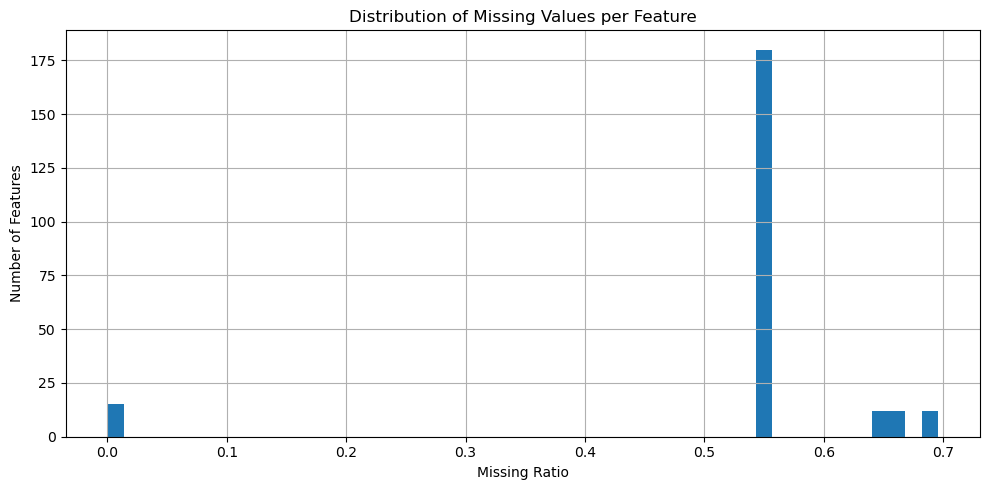

In [101]:
plt.figure(figsize=(10, 5))
missing_ratio.hist(bins=50)
plt.title('Distribution of Missing Values per Feature')
plt.xlabel('Missing Ratio')
plt.ylabel('Number of Features')
plt.tight_layout()
plt.show()

#### `8-4`  `Missingness Matrix` <a name="missingmatrix"></a>

This visualisation can help reveal whether missing values occur in blocks or patterns.

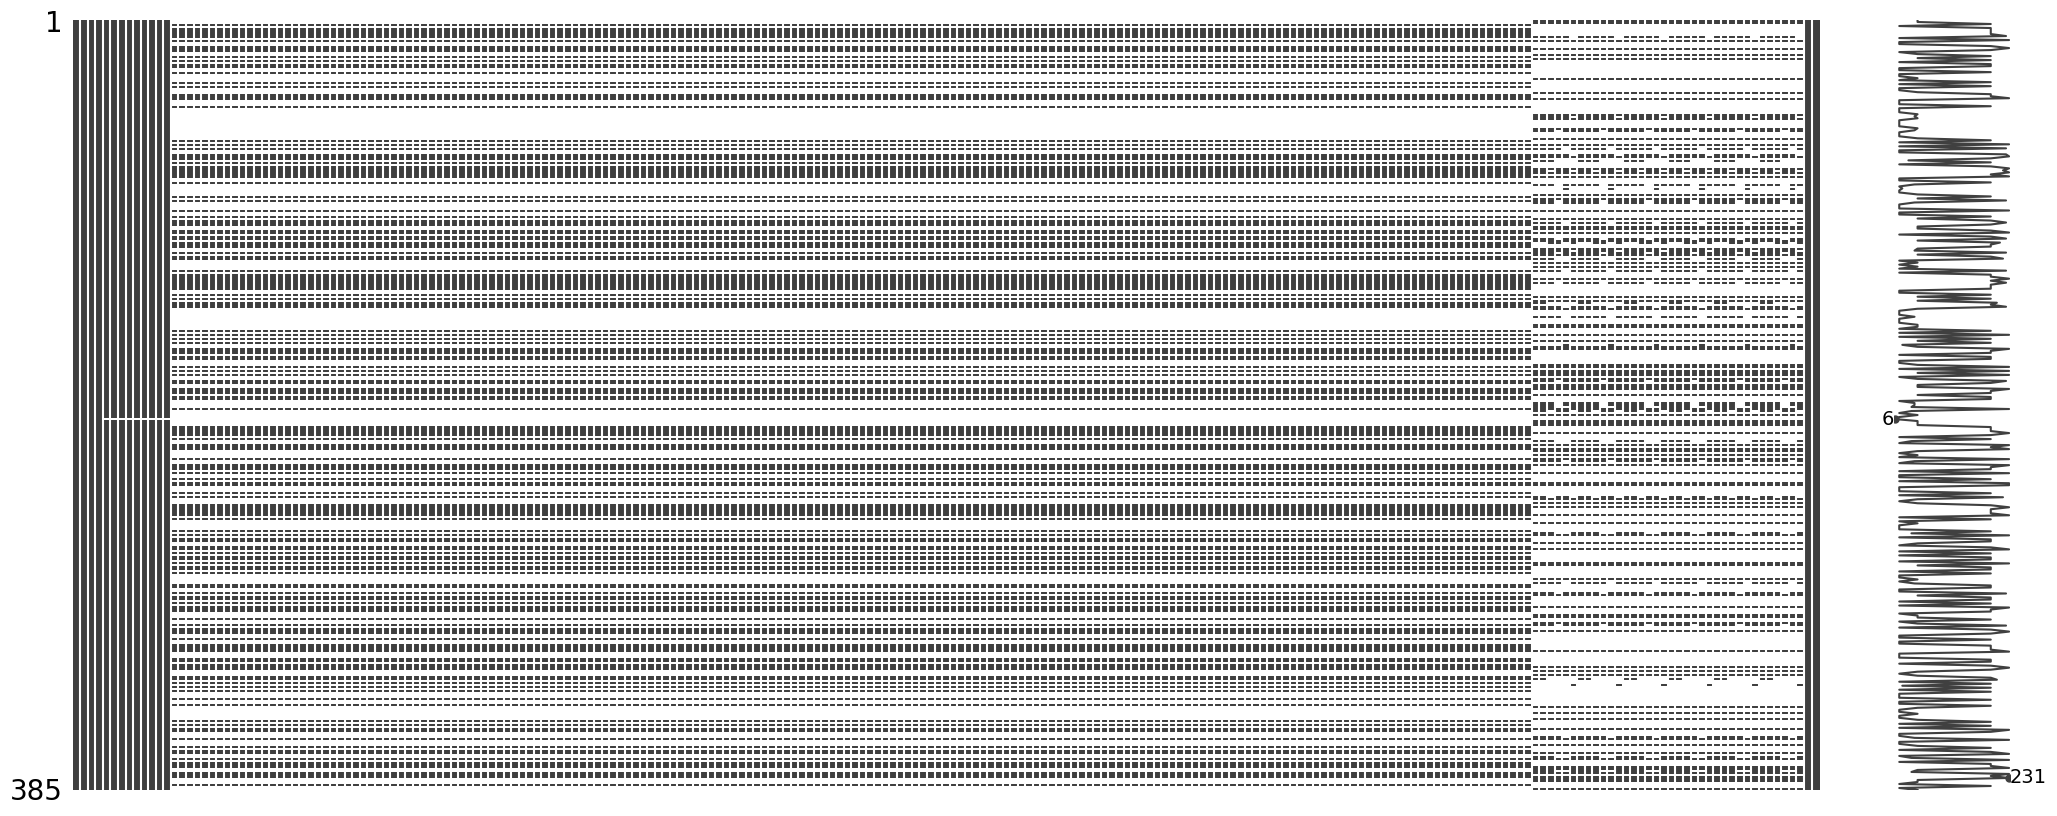

In [103]:
if MISSINGNO_AVAILABLE:
    msno.matrix(df_early)
    plt.show()
else:
    print("missingno is not installed. Skip this optional visualisation or install it first.")

#### `8-5`  `Missing Data Interpretation` <a name="missinginterpretation"></a>

Early-window clinical data is sparse. This is realistic in healthcare because not every lab test or vital sign is available immediately for every patient.

The key modelling decision is to avoid using later windows to fill missing values, because that would introduce temporal leakage.

### `9-`  `Feature Reliability Decision` <a name="featurereliability"></a>

#### `9-1`  `Missingness Threshold` <a name="missingthreshold"></a>

Decision:

Drop features with more than **60% missing values** in the early-window dataset.

This removes highly unreliable features while keeping potentially useful clinical features with moderate missingness.

#### `9-2`  `Identify High-Missing Features` <a name="identifyhighmissing"></a>

In [108]:
threshold = 0.60
high_missing_cols = missing_ratio[missing_ratio > threshold].index.tolist()

print("Number of columns with >60% missing:", len(high_missing_cols))
print("Columns to drop:")
print(high_missing_cols)

Number of columns with >60% missing: 36
Columns to drop:
['RESPIRATORY_RATE_DIFF_REL', 'RESPIRATORY_RATE_DIFF', 'RESPIRATORY_RATE_MEDIAN', 'RESPIRATORY_RATE_MAX', 'RESPIRATORY_RATE_MEAN', 'RESPIRATORY_RATE_MIN', 'TEMPERATURE_DIFF', 'TEMPERATURE_MEAN', 'TEMPERATURE_MAX', 'TEMPERATURE_DIFF_REL', 'TEMPERATURE_MEDIAN', 'TEMPERATURE_MIN', 'OXYGEN_SATURATION_DIFF', 'OXYGEN_SATURATION_MEDIAN', 'OXYGEN_SATURATION_MAX', 'OXYGEN_SATURATION_DIFF_REL', 'OXYGEN_SATURATION_MIN', 'OXYGEN_SATURATION_MEAN', 'HEART_RATE_MEAN', 'HEART_RATE_MEDIAN', 'HEART_RATE_DIFF_REL', 'HEART_RATE_MIN', 'HEART_RATE_MAX', 'HEART_RATE_DIFF', 'BLOODPRESSURE_SISTOLIC_MIN', 'BLOODPRESSURE_SISTOLIC_DIFF', 'BLOODPRESSURE_DIASTOLIC_MIN', 'BLOODPRESSURE_SISTOLIC_DIFF_REL', 'BLOODPRESSURE_DIASTOLIC_MEAN', 'BLOODPRESSURE_SISTOLIC_MEAN', 'BLOODPRESSURE_DIASTOLIC_DIFF_REL', 'BLOODPRESSURE_DIASTOLIC_DIFF', 'BLOODPRESSURE_DIASTOLIC_MEDIAN', 'BLOODPRESSURE_SISTOLIC_MEDIAN', 'BLOODPRESSURE_SISTOLIC_MAX', 'BLOODPRESSURE_DIASTOLIC_MAX']


`Validation:`

`36` columns above the 60% missingness threshold.

#### `9-3`  `Drop High-Missing Features` <a name="drophighmissing"></a>

In [111]:
df_clean = df_early.drop(columns=high_missing_cols).copy()

print("Shape before dropping high-missing columns:", df_early.shape)
print("Shape after dropping high-missing columns:", df_clean.shape)
print("Max missing ratio after drop:", df_clean.isnull().mean().max())

Shape before dropping high-missing columns: (385, 231)
Shape after dropping high-missing columns: (385, 195)
Max missing ratio after drop: 0.5532467532467532


`Validation:`

- 36 columns dropped
- maximum remaining missingness around 55%

#### `9-4`  `Drop Non-Feature Window Column` <a name="dropwindow"></a>

After filtering to the 0-2 window, `WINDOW` is constant and no longer useful as a model feature.

In [114]:
if 'WINDOW' in df_clean.columns:
    df_model = df_clean.drop(columns=['WINDOW']).copy()
else:
    df_model = df_clean.copy()

print("Shape after removing WINDOW if present:", df_model.shape)

Shape after removing WINDOW if present: (385, 194)


Important:

`PATIENT_VISIT_IDENTIFIER` is retained for traceability during analysis, but it must be excluded from model features later.

### `10-`  `Feature Type Definition` <a name="featuretypedefinition"></a>

#### `10-1`  `Define Target and Identifier Columns` <a name="targetandid"></a>

In [118]:
target_col = 'ICU'
id_col = 'PATIENT_VISIT_IDENTIFIER'

print("Target column:", target_col)
print("Identifier column:", id_col)

Target column: ICU
Identifier column: PATIENT_VISIT_IDENTIFIER


#### `10-2`  `Define Categorical Features` <a name="definecategorical"></a>

In [120]:
categorical_cols = [
    'AGE_PERCENTIL',
    'AGE_ABOVE65',
    'GENDER',
    'DISEASE GROUPING 1',
    'DISEASE GROUPING 2',
    'DISEASE GROUPING 3',
    'DISEASE GROUPING 4',
    'DISEASE GROUPING 5',
    'DISEASE GROUPING 6',
    'HTN',
    'IMMUNOCOMPROMISED',
    'OTHER'
]

# Keep only categorical columns that still exist after feature dropping
categorical_cols = [col for col in categorical_cols if col in df_model.columns]

print("Number of categorical columns:", len(categorical_cols))
print(categorical_cols)

Number of categorical columns: 12
['AGE_PERCENTIL', 'AGE_ABOVE65', 'GENDER', 'DISEASE GROUPING 1', 'DISEASE GROUPING 2', 'DISEASE GROUPING 3', 'DISEASE GROUPING 4', 'DISEASE GROUPING 5', 'DISEASE GROUPING 6', 'HTN', 'IMMUNOCOMPROMISED', 'OTHER']


#### `10-3`  `Define Numeric Features` <a name="definenumeric"></a>

In [122]:
numeric_cols = [
    col for col in df_model.columns
    if col not in categorical_cols + [target_col, id_col]
]

print("Number of numeric columns:", len(numeric_cols))
print("First 10 numeric columns:")
print(numeric_cols[:10])

Number of numeric columns: 180
First 10 numeric columns:
['ALBUMIN_MEDIAN', 'ALBUMIN_MEAN', 'ALBUMIN_MIN', 'ALBUMIN_MAX', 'ALBUMIN_DIFF', 'BE_ARTERIAL_MEDIAN', 'BE_ARTERIAL_MEAN', 'BE_ARTERIAL_MIN', 'BE_ARTERIAL_MAX', 'BE_ARTERIAL_DIFF']


#### `10-4`  `Feature Type Sanity Checks` <a name="featuresanitychecks"></a>

In [124]:
overlap = set(categorical_cols).intersection(set(numeric_cols))
missing_categorical = [col for col in categorical_cols if col not in df_model.columns]

print("Categorical/Numeric overlap(overlap should be an empty set):", overlap)
print("Categorical columns missing from dataframe (no missing categorical columns):", missing_categorical)


Categorical/Numeric overlap(overlap should be an empty set): set()
Categorical columns missing from dataframe (no missing categorical columns): []


In [125]:
df_model.shape

(385, 194)

In [126]:
print("Total columns:", len(df_model.columns))
print("Categorical columns:", len(categorical_cols))
print("Numeric columns:", len(numeric_cols))
print("Patient_id column (PATIENT_VISIT_IDENTIFIER): 1")
print("Target column (ICU): 1")

print("------------------\n")

Total columns: 194
Categorical columns: 12
Numeric columns: 180
Patient_id column (PATIENT_VISIT_IDENTIFIER): 1
Target column (ICU): 1
------------------



`Observation:`

- Dataset is stable, reusable, and final modeling-ready dataset
- At that point we have:
    - Correct dataset structure (patient-level)
    - Correct target
    - Cleaned features (missing handled at feature level)
    - Defined feature types
    - No further structural changes expected
    - the dataframe has moved from a raw dataset into a structured ML input design.

---

### `11-`  `Save Final Dataset` <a name="save"></a>

In [129]:
import os

# Create directory if not exists
os.makedirs('../data/processed', exist_ok=True)

# Save dataset
df_model.to_csv('../data/processed/df_model.csv', index=False)

print("Dataset saved successfully")
print("Final shape:", df_model.shape)

Dataset saved successfully
Final shape: (385, 194)


### `12-`  `Notebook Summary` <a name="notebooksummary"></a>

#### `12-1`  `Key Findings` <a name="keyfindings"></a>

This notebook established the following:

- the raw dataset contains 1925 rows and 385 patients
- each patient appears across multiple observation windows
- the final modelling unit should be one patient, not one window-level row
- the project uses only the 0-2 hour window for early prediction
- the patient-level target is future ICU admission
- high-missing features above 60% missingness are removed
- remaining features are separated into categorical and numeric groups
- final modeling-ready dataset shape: (385, 194)

#### `12-2`  `Next Notebook` <a name="nextnotebook"></a>

The next notebook, `02_model_experiments.ipynb`, will cover:

- train/test split
- sklearn preprocessing pipeline
- missing-value imputation
- categorical encoding
- model training
- model comparison
- final model selection
- feature importance analysis